# 1. Theory
* Data: $X_1, \ldots, X_n$ are i.i.d. with pdf $f(x|\theta)$. Hence, the likelihood is
$$L(\theta|X_{1:n})=\prod_{i=1}^n f(X_i|\theta).$$
* Prior: $\pi(\theta)$
* Posterior: $$p(\theta|X_{1:n})=\frac{L(\theta|X_{1:n})\pi(\theta)}{\int L(u|X_{1:n})\pi(u)du}.$$
* Goal: approximate $p(\theta|X_{1:n})$ using $q(\theta)$.
* We wish to find a distribution $q(\theta)$ to minimize the following KL divergence:
\[
\begin{aligned}
KL(q(\theta)||p(\theta|X_{1:n}))&= E_{q(\theta)}\left[\log\left(\frac{q(\theta)}{p(\theta|X_{1:n})}\right)\right]\\
&=E_{q(\theta)}\left[\log(q(\theta))\right]-E_{q(\theta)}\left[\log(p(\theta|X_{1:n}))\right]\\
&=E_{q(\theta)}\left[\log(q(\theta))\right]-E_{q(\theta)}\left[\log(L(\theta|X_{1:n})\pi(\theta))\right]+\int L(u|X_{1:n})\pi(u)du\\
&=-E_{q(\theta)}\left[\log(L(\theta|X_{1:n}))\right]+KL(q(\theta)||\pi(\theta))+{\tt constant},
\end{aligned}
\]
where the constant does not depend on $q$. Therefore, minimizing the KL divergence is equivalent to maximizing the following Evidence Lower Bound (ELBO):
$$
ELBO=E_{q(\theta)}\left[\log(L(\theta|X_{1:n}))\right]-KL(q(\theta)||\pi(\theta)).
$$


# 2. Model
* Data: $X_1, \ldots, X_n \sim Bin(1, p)$
* Prior: $p=\sigma(\theta)$ with $\theta \sim \pi(\theta)=\frac{\lambda}{2}e^{-\lambda|\theta|}$ and $\sigma(\theta)=\frac{1}{1+e^{-\theta}}$
* Variational Approximation: $q(\theta)=N(\mu_q, \sigma_q^2)$
* Likelihood: $L(\theta|X_{1:n})=[\sigma(\theta)]^{\sum_{i=1}^n X_i}[1-\sigma(\theta)]^{n-\sum_{i=1}^n X_i}$
* Maximize Evidence Lower Bound (ELBO):
$$\max_{\mu_q, \sigma_q}ELBO=E_{q(\theta)}\left[\log(L(\theta|X_{1:n}))\right]-KL(q(\theta)||\pi(\theta))$$
* Calculation:
  1. Initial $\mu_q, \sigma_q$
  2. Generate sample $\theta_1, \ldots, \theta_K$ from $q(\theta)=N(\mu_q, \sigma_q^2)$
  3. Approximation:
  \begin{aligned}
    E_{q(\theta)}\left[\log(L(\theta|X_{1:n}))\right]&\approx \frac{1}{K}\sum_{k=1}^K \log(L(\theta_k|X_{1:n})) \\
    &=\frac{1}{K}\sum_{i=1}^n \sum_{k=1}^K \left[X_i \log(\sigma(\theta_k))+\left(1-X_i\right) \log(1-\sigma(\theta_k))\right]
  \end{aligned}
  1. Approximation: 
  \begin{aligned}
 KL(q(\theta)|| \pi(\theta))&= \int q(\theta)\log\left(\frac{q(\theta)}{\pi(\theta)}\right)d\theta\\
 &= E_{q(\theta)}\left[\log\left(\frac{q(\theta)}{\pi(\theta)}\right)\right]\\
 &= E_{q(\theta)}\left[\log\left({q(\theta)}\right)\right]-E_{q(\theta)}\left[\log\left({\pi(\theta)}\right)\right]\\
 &\approx \frac{1}{K} \sum_{k=1}^K \log(q(\theta_k))-\frac{1}{K} \sum_{k=1}^K \log(\pi(\theta_k))\\
 &= -\frac{1}{2}\log(2\pi)-\log(\sigma_q)-\frac{1}{2\sigma_q^2 K} \sum_{k=1}^K (\theta_k-\mu_q)^2\\
 &\quad\;-\log(\lambda/2)+\frac{\lambda}{K}\sum_{k=1}^K  |\theta_k|\\
 &= -\log(\sigma_q)-\frac{1}{2\sigma_q^2 K} \sum_{k=1}^K (\theta_k-\mu_q)^2+\frac{\lambda}{K}\sum_{k=1}^K  |\theta_k|+{\tt Constant},
  \end{aligned}
  where the constant does not depend on $\mu_q, \sigma_q$.
  1. Maximize ELBO using gradient algorithm: 
  $$ELBO(\mu_q, \sigma_q)=E_{q(\theta)}\left[\log(L(\theta|X_{1:n}))\right]-KL(q(\theta)|| \pi(\theta))$$
  1. Repeat Step 2-5 until convergence.

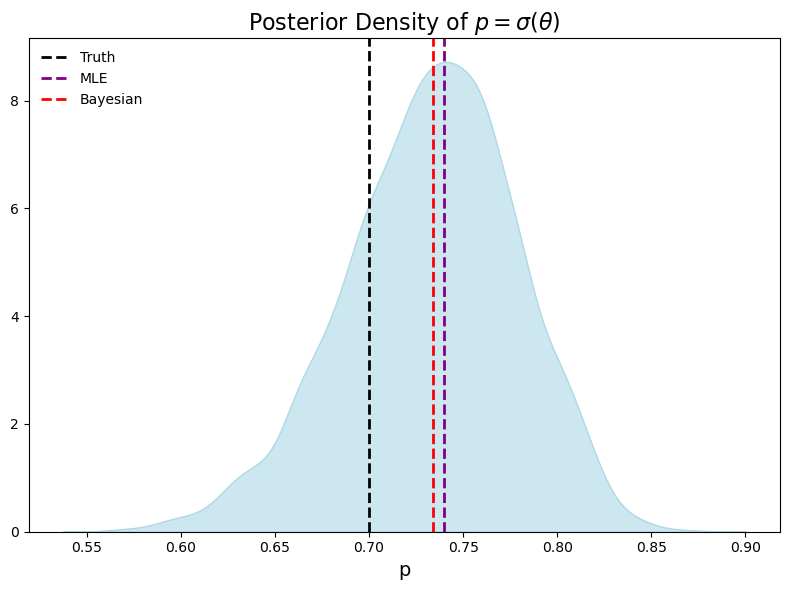

True parameter (p): 0.7
Bayesian estimator: 0.734174907207489
MLE estimator: 0.7400000095367432


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
torch.manual_seed(1)
np.random.seed(1)

# Simulated Bernoulli data
n = 100
p_true = 0.7
X = torch.tensor(np.random.binomial(1, p_true, n), dtype=torch.float32)

# Prior parameters (Laplace prior)
lambda_ = torch.tensor(1.0, dtype=torch.float32)

# Variational parameters
mu_q = torch.tensor(0.0, requires_grad=True, dtype=torch.float32)
log_sigma_q = torch.tensor(0.0, requires_grad=True, dtype=torch.float32)

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

# ELBO function
def elbo(mu_q, log_sigma_q):
    sigma_q = torch.exp(log_sigma_q)
    
    K = 1000  # Monte Carlo samples
    epsilon = torch.randn(K)  # K samples from N(0, 1)
    theta_samples = mu_q + sigma_q * epsilon  # theta_k from N(mu_q, sigma_q^2)
    
    a1 = X.view(n, 1)  # vector of X, shape [n, 1]
    a2 = torch.log(sigmoid(theta_samples)).view(1, K)  # vector of log(sigma(theta_k)), shape [1, K]
    a3 = torch.log(1 - sigmoid(theta_samples)).view(1, K)  # vector of log(1-sigma(theta_k)), shape [1, K]
    log_likelihood = torch.sum(torch.matmul(a1, a2) + torch.matmul(1 - a1, a3)) / K
    
    log_q_theta = -0.5 *  torch.log(torch.tensor(2 * np.pi)) - log_sigma_q - 0.5 * ((theta_samples - mu_q) / sigma_q)**2  # log of N(mu_q, sigma_q^2)
    log_p_theta = torch.log(lambda_ / 2) - lambda_ * torch.abs(theta_samples)  # log of prior 
    kl_div = torch.mean(log_q_theta - log_p_theta)
    
    return log_likelihood - kl_div

# Optimizer
optimizer = torch.optim.Adam([mu_q, log_sigma_q], lr=0.05)

# Training loop
for epoch in range(100):
    optimizer.zero_grad()
    loss = -elbo(mu_q, log_sigma_q)
    loss.backward()
    optimizer.step()

# Final variational parameters
mu_q_final = mu_q.item()
sigma_q_final = torch.exp(log_sigma_q).item()

# Visualization of the posterior
posterior_samples = np.random.normal(mu_q_final, sigma_q_final, 5000)
posterior_p = sigmoid(torch.tensor(posterior_samples)).numpy()

# Plotting the results
plt.figure(figsize=(8, 6))
sns.kdeplot(posterior_p, fill=True, color="lightblue", alpha=0.6)

# Plot vertical lines for Truth, MLE, and Bayesian estimators
plt.axvline(p_true, color='black', linestyle='--', label='Truth', linewidth=2)
plt.axvline(torch.mean(X).item(), color='purple', linestyle='--', label='MLE', linewidth=2)
plt.axvline(sigmoid(mu_q).item(), color='red', linestyle='--', label='Bayesian', linewidth=2)

# Labels and title
plt.title(r'Posterior Density of $p = \sigma(\theta)$', fontsize=16)
plt.xlabel('p', fontsize=14)
plt.ylabel('', fontsize=14)

# Customizing the legend
plt.legend(loc='upper left', frameon=False)

# Show the plot
plt.tight_layout()
plt.show()

# Display parameter values
print(f"True parameter (p): {p_true}")
print(f"Bayesian estimator: {sigmoid(mu_q).item()}")
print(f"MLE estimator: {torch.mean(X).item()}")

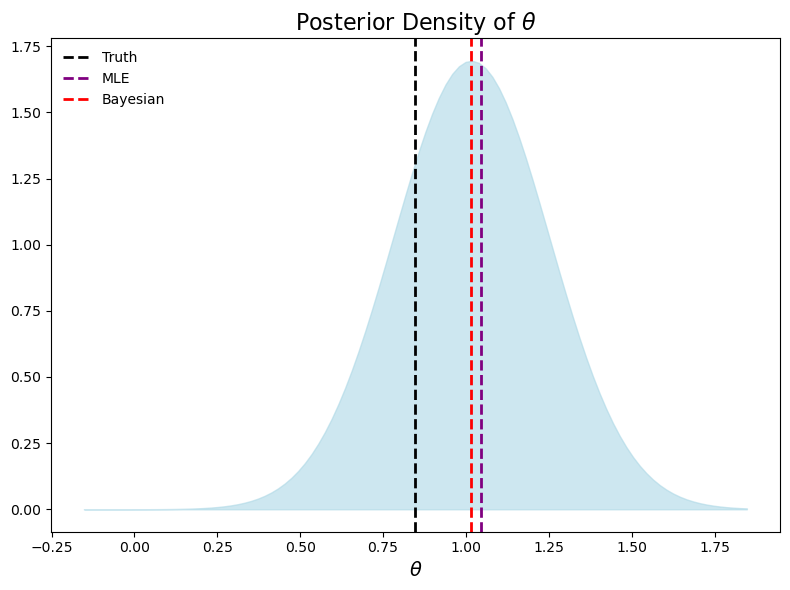

True parameter (theta): 0.8472978603872034
Bayesian estimator: 1.015908746814646
MLE estimator: 1.0459686047499603


In [2]:
from scipy.stats import norm

def sigmoid_inv(x):
    return np.log(x/(1-x))

theta_true = sigmoid_inv(p_true)
x_values = np.linspace(theta_true - 1, theta_true + 1, 100)

# Plot the posterior density
plt.figure(figsize=(8, 6))

# Plot the normal distribution (posterior density)
plt.fill_between(x_values, norm.pdf(x_values, mu_q_final, sigma_q_final), color="lightblue", alpha=0.6)

# Plot vertical lines for Truth, MLE, and Bayesian estimates
plt.axvline(sigmoid_inv(p_true), color='black', linestyle='--', label="Truth", linewidth=2)
plt.axvline(sigmoid_inv(np.mean(X.numpy())), color='purple', linestyle='--', label="MLE", linewidth=2)
plt.axvline(sigmoid_inv(sigmoid(mu_q).item()), color='red', linestyle='--', label="Bayesian", linewidth=2)

# Labels and title
plt.title(r'Posterior Density of $\theta$', fontsize=16)
plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel('', fontsize=14)

# Customize legend
plt.legend(loc="upper left", frameon=False)

# Show the plot
plt.tight_layout()
plt.show()

# Display the parameter values
print(f"True parameter (theta): {theta_true}")
print(f"Bayesian estimator: {sigmoid_inv(sigmoid(mu_q).item())}")
print(f"MLE estimator: {sigmoid_inv(np.mean(X.numpy()))}")